### **Reactor**

In [35]:
#Helper function to show the reactor results

def display_result(result: list):
    for r in range(len(result)):
        print(r + 1, ". result", sep="")
        for i in range(len(result[r].product_sets)):
            print("  ", i + 1, ". product set:", sep="")
            for j in range(len(result[r].product_sets[i].products)):
                print("    ", j + 1, ". product", sep="")
                display(result[r].product_sets[i].products[j])

In [ ]:
%%sql


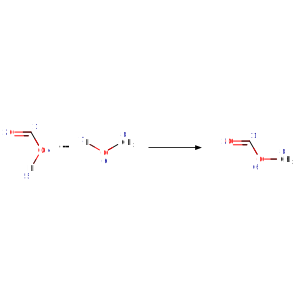

In [24]:
from chemaxon import import_mol, export_mol, single_input, parallel, Mode, ReactorOptions, ResultType, ReactionRules

reactants1 = [import_mol("CC(O)=O"), import_mol("CCC(O)=O")]
reactants2 = [import_mol("CO"), import_mol("CCCCO")]
reaction = import_mol("[H:5][O:4][CH:1]=[O:2].[H:7][O:6][CH3:8]>>[CH3:8][O:6][CH:1]=[O:2]")
display(reaction)

1. result
  1. product set:
    1. product


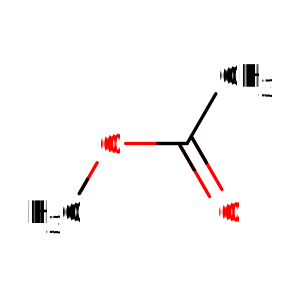

In [36]:
result = single_input(reaction, [reactants1[0], reactants2[0]])
display_result([result])

1. result
  1. product set:
    1. product


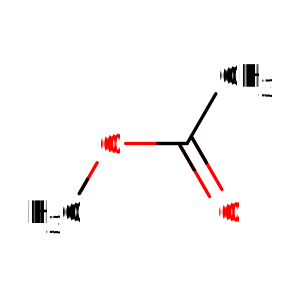

2. result
  1. product set:
    1. product


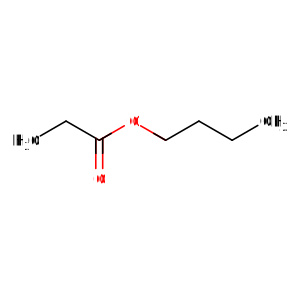

In [37]:
result = parallel(Mode.SEQUENTIAL, reaction, [reactants1, reactants2])
display_result(result)

1. result
  1. product set:
    1. product


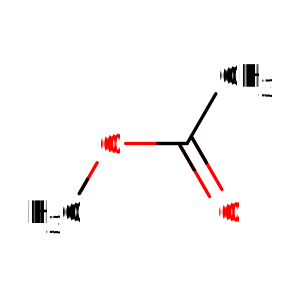

2. result
  1. product set:
    1. product


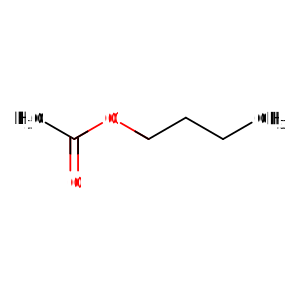

3. result
  1. product set:
    1. product


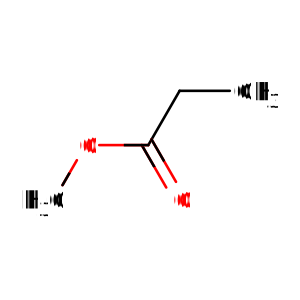

4. result
  1. product set:
    1. product


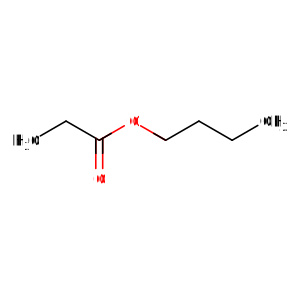

In [38]:
result = parallel(Mode.COMBINATORIAL, reaction, [reactants1, reactants2])
display_result(result)

Results without reaction rules
1. result
  1. product set:
    1. product


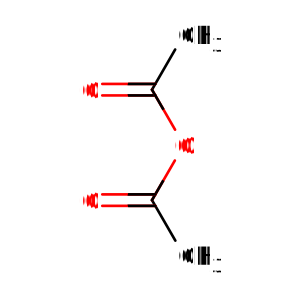

2. result
  1. product set:
    1. product


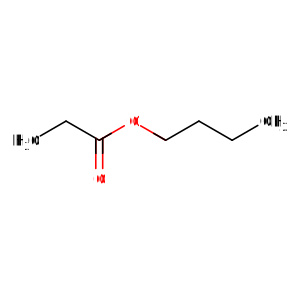

Results with reaction rules
1. result
  1. product set:
    1. product


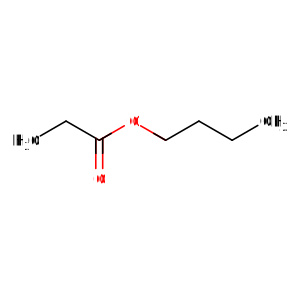

In [39]:
all_reactants = [[reactants1[0], reactants1[1]], [reactants1[0], reactants2[1]]]
result = parallel(Mode.SEQUENTIAL, reaction, all_reactants)
print("Results without reaction rules")
display_result(result)

print("Results with reaction rules")
rules = ReactionRules()
rules.reactivity = "match(reactant(1), alcohol) or match(reactant(1), phenol)"
result = parallel(Mode.SEQUENTIAL, reaction, all_reactants, rules=rules)
display_result(result)

1. result
  1. product set:
    1. product


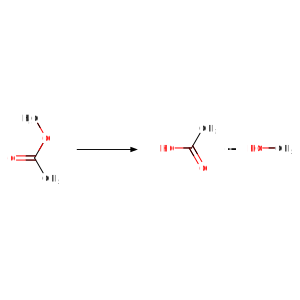

2. result
  1. product set:
    1. product


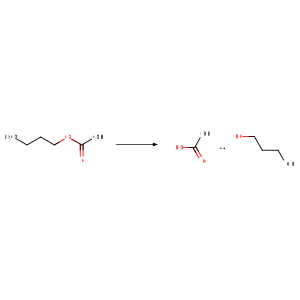

In [40]:
options = ReactorOptions()
options.reverse = True
options.result_type = ResultType.REACTION
reverse_reactants = [[import_mol("COC(C)=O"), import_mol("CCCCOC(C)=O")]]
result = parallel(Mode.SEQUENTIAL, reaction, reverse_reactants, options=options)
display_result(result)

Ratio 1:1
1. result
  1. product set:
    1. product


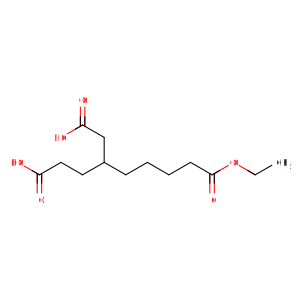

  2. product set:
    1. product


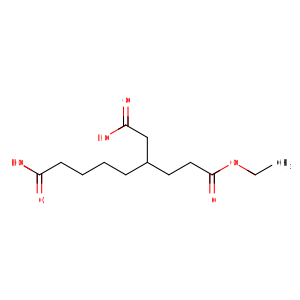

  3. product set:
    1. product


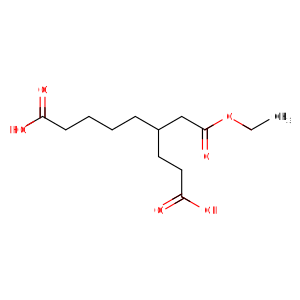

Ratio 1:2
1. result
  1. product set:
    1. product


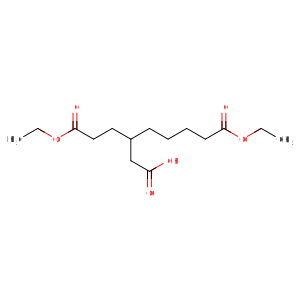

  2. product set:
    1. product


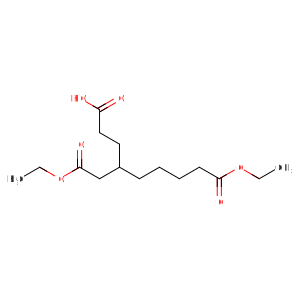

  3. product set:
    1. product


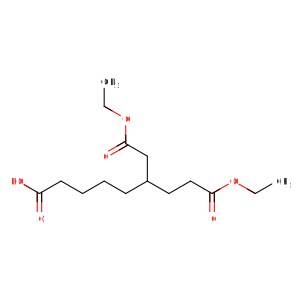

Ratio 1:3
1. result
  1. product set:
    1. product


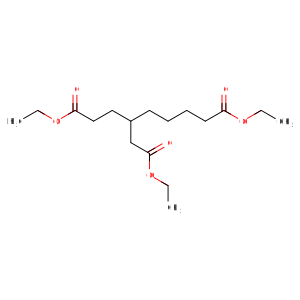

In [41]:
reaction = import_mol("[H:5][O:4][CH:1]=[O:2].[H:7][O:6][CH3:8]>>[CH3:8][O:6][CH:1]=[O:2]")
all_reactant = [[import_mol("OC(=O)CCCCC(CCC(O)=O)CC(O)=O")], [import_mol("CCO")]]
options = ReactorOptions()
print("Ratio 1:1")
options.ratio = [1, 1]
result = parallel(Mode.SEQUENTIAL, reaction, all_reactant, options=options)
display_result(result)

print("Ratio 1:2")
options.ratio = [1, 2]
result = parallel(Mode.SEQUENTIAL, reaction, all_reactant, options=options)
display_result(result)

print("Ratio 1:3")
options.ratio = [1, 3]
result = parallel(Mode.SEQUENTIAL, reaction, all_reactant, options=options)
display_result(result)